# 05 · K-Nearest Neighbors (KNN) and Support Vector Machines (SVM), Explained Visually

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/05-knn-and-svm/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Measure a distance, and watch one feature take over

In [1]:
import numpy as np

# Each customer: [age in years, yearly income in dollars]
A = np.array([25, 50_000])   # the new customer
B = np.array([60, 51_000])   # 35 years older, almost the same income
C = np.array([25, 70_000])   # the same age, $20,000 more income

print(f"A -> B: {np.linalg.norm(A - B):,.1f}")
print(f"A -> C: {np.linalg.norm(A - C):,.1f}")
# A -> B: 1,000.6
# A -> C: 20,000.0

A -> B: 1,000.6
A -> C: 20,000.0


- `np.linalg.norm(A - B)` is the Euclidean distance: subtract, square, add up, take the square root.
- By these numbers B is 20 times closer to A than C is, even though B is 35 years older. Income's big numbers drown out age completely.

### Step 2 · A dataset where only age matters

In [2]:
import pandas as pd

rng = np.random.default_rng(34)
n = 300
bought = np.repeat([1, 0], n // 2)       # 1 = bought reading glasses, 0 = didn't
age = np.where(bought == 1, rng.normal(52, 8, n), rng.normal(32, 8, n))   # buyers are older
age = age.clip(18, 80).round().astype(int)
income = rng.uniform(20_000, 120_000, n).round(-2).astype(int)           # no link to buying at all

df = pd.DataFrame({"age": age, "income": income, "bought": bought})
print(df.sample(5, random_state=1))
print(df.groupby("bought")[["age", "income"]].mean().round())
#      age  income  bought
# 189   33   88000       0
# 123   59   96000       1
# 185   27   77800       0
# 213   24   96500       0
# 106   47   47800       1
#          age   income
# bought
# 0       32.0  71988.0
# 1       52.0  70853.0

     age  income  bought
189   33   88000       0
123   59   96000       1
185   27   77800       0
213   24   96500       0
106   47   47800       1
         age   income
bought               
0       32.0  71988.0
1       52.0  70853.0


- Meet the 300 customers of an optician's shop. Buyers are about 20 years older on average (52 vs. 32), while both groups earn about the same. Age is the useful feature; income is pure noise.
- But income's numbers are thousands of times bigger than age's. That's the trap.

### Step 3 · KNN without scaling: a coin flip

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = df[["age", "income"]].to_numpy()
y = df["bought"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)                  # just stores the training data
print("Test accuracy without scaling:", round(knn_raw.score(X_test, y_test), 2))

dist, idx = knn_raw.kneighbors([A])            # A's 5 nearest training customers
neighbors = pd.DataFrame(X_train[idx[0]], columns=["age", "income"])
neighbors["bought"] = y_train[idx[0]]
print(neighbors)
print("Prediction for A:", knn_raw.predict([A]))
# Test accuracy without scaling: 0.47
#    age  income  bought
# 0   40   49600       1
# 1   33   49100       0
# 2   28   51000       0
# 3   41   51100       1
# 4   59   48900       1
# Prediction for A: [1]

Test accuracy without scaling: 0.47
   age  income  bought
0   40   49600       1
1   33   49100       0
2   28   51000       0
3   41   51100       1
4   59   48900       1
Prediction for A: [1]


- For classifiers, `score` returns **accuracy**: the share of test customers the model got right. 0.47 is no better than flipping a coin.
- `kneighbors` shows who voted. A's "nearest" neighbors all earn about $50,000, but their ages run from 28 to 59, and three of them bought glasses. So KNN predicts that our 25-year-old will buy reading glasses.
- `stratify=y` keeps the same share of buyers in the training and the test set.

### Step 4 · Standardize, using the training data only

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)                  # learns each feature's mean and spread from the TRAINING data only
print(pd.DataFrame({"mean": scaler.mean_, "std": scaler.scale_}, index=["age", "income"]).round())

A_z, B_z, C_z = scaler.transform([A, B, C])
print(f"A -> B: {np.linalg.norm(A_z - B_z):.2f}")
print(f"A -> C: {np.linalg.norm(A_z - C_z):.2f}")
#            mean      std
# age        42.0     12.0
# income  71794.0  28403.0
# A -> B: 2.88
# A -> C: 0.70

           mean      std
age        42.0     12.0
income  71794.0  28403.0
A -> B: 2.88
A -> C: 0.70


- `fit` only measures each column's mean and standard deviation. `transform` then applies $z = (x - \mu) / \sigma$ with those numbers.
- In standard units, B is now four times farther from A than C is. Age finally counts, just like in the right half of the scaling picture.

### Step 5 · Scaler and KNN in one Pipeline

In [5]:
from sklearn.pipeline import make_pipeline

knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn.fit(X_train, y_train)            # the scaler learns from X_train, then KNN stores the scaled points
print("Test accuracy with scaling:", round(knn.score(X_test, y_test), 2))
print("Prediction for A:", knn.predict([A]))
# Test accuracy with scaling: 0.92
# Prediction for A: [0]

Test accuracy with scaling: 0.92
Prediction for A: [0]


- Same data, same algorithm, same k. Scaling alone lifts the accuracy from 0.47 to 0.92, and A is now predicted not to buy.
- When you call `knn.score(X_test, ...)` or `knn.predict(...)`, the pipeline scales the new data with the mean and standard deviation it learned from the training set. The test set never touches the scaler.
- From here on, every distance-based model gets its own scaler inside a pipeline.

### Step 6 · Choose k

In [6]:
for k in [1, 5, 15, 51, 201]:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    print(f"k = {k:>3}   train: {model.score(X_train, y_train):.2f}   test: {model.score(X_test, y_test):.2f}")
# k =   1   train: 1.00   test: 0.85
# k =   5   train: 0.94   test: 0.92
# k =  15   train: 0.91   test: 0.93
# k =  51   train: 0.91   test: 0.95
# k = 201   train: 0.90   test: 0.87

k =   1   train: 1.00   test: 0.85
k =   5   train: 0.94   test: 0.92
k =  15   train: 0.91   test: 0.93
k =  51   train: 0.91   test: 0.95


k = 201   train: 0.90   test: 0.87


- k = 1 scores a perfect 1.00 on the training data, because every training point's nearest neighbor is itself. That's memorizing, and the test score (0.85) tells the truth.
- The test score climbs as k grows, then drops at k = 201, where 201 of the 225 training customers vote on every single prediction. The true boundary here is simple (roughly "older than 42?"), so a big k fails late; on curvier data, like the moons in the "Choosing k" picture, it fails much sooner.
- We picked k by peeking at the test set, which is fine for a demo. In real projects, use cross-validation (lesson 08) so the test set stays a fair final exam.

### Step 7 · SVM: find the widest street

In [7]:
from sklearn.svm import SVC

svm = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm.fit(X_train, y_train)
print("Test accuracy:", round(svm.score(X_test, y_test), 2))
print("Support vectors:", svm[-1].n_support_.sum(), "of", len(X_train), "training points")
print("Prediction for A:", svm.predict([A]))
# Test accuracy: 0.95
# Support vectors: 55 of 225 training points
# Prediction for A: [0]

Test accuracy: 0.95
Support vectors: 55 of 225 training points
Prediction for A: [0]


- `SVC` is scikit-learn's support vector classifier, and `kernel="linear"` asks for a straight boundary. The scaler comes along in the pipeline, because an SVM measures distances too.
- `svm[-1]` grabs the last step of the pipeline (the SVC itself), and `n_support_` counts its support vectors in each class.
- The two classes overlap, so many customers sit inside the street, and each of them counts as a support vector.

### Step 8 · Turn the C knob

In [8]:
for c in [0.01, 1, 100]:
    svm_c = make_pipeline(StandardScaler(), SVC(kernel="linear", C=c))
    svm_c.fit(X_train, y_train)
    width = 2 / np.linalg.norm(svm_c[-1].coef_)      # street width = 2 / ||w||
    n_sv = svm_c[-1].n_support_.sum()
    acc = svm_c.score(X_test, y_test)
    print(f"C = {c:<5}  street width: {width:.2f}   support vectors: {n_sv:>3}   test accuracy: {acc:.2f}")
# C = 0.01   street width: 2.35   support vectors: 162   test accuracy: 0.93
# C = 1      street width: 0.70   support vectors:  55   test accuracy: 0.95
# C = 100    street width: 0.55   support vectors:  45   test accuracy: 0.95

C = 0.01   street width: 2.35   support vectors: 162   test accuracy: 0.93
C = 1      street width: 0.70   support vectors:  55   test accuracy: 0.95
C = 100    street width: 0.55   support vectors:  45   test accuracy: 0.95


- For a linear SVM, `coef_` holds the weights $w$, so `2 / np.linalg.norm(coef_)` is the street width from the formula above (in standardized units).
- Cheap violations (C = 0.01) give a wide street with 162 points on or inside it. Expensive ones (C = 100) squeeze the street until only 45 points touch or enter it.
- Here C barely moves the accuracy, but on messier data it can matter a lot. Tune it the way you tune k.

### Step 9 · The kernel trick on circles

In [9]:
from sklearn.datasets import make_circles

Xc, yc = make_circles(n_samples=300, factor=0.4, noise=0.1, random_state=0)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, random_state=42, stratify=yc)

for kernel in ["linear", "rbf"]:
    svm_k = make_pipeline(StandardScaler(), SVC(kernel=kernel))
    svm_k.fit(Xc_train, yc_train)
    print(f"{kernel:>6} kernel -> test accuracy: {svm_k.score(Xc_test, yc_test):.2f}")
# linear kernel -> test accuracy: 0.44
#    rbf kernel -> test accuracy: 1.00

linear kernel -> test accuracy: 0.44
   rbf kernel -> test accuracy: 1.00


- `make_circles` makes two noisy rings: class 1 inside, class 0 around it. No straight line can separate them, so the linear SVM does no better than guessing.
- The RBF kernel draws a curved boundary around the inner ring, as if it had lifted the data like in the animation.
- Both features here already share the same scale, so the scaler changes little. Keeping it in the pipeline is still a good habit for SVMs.

### See it

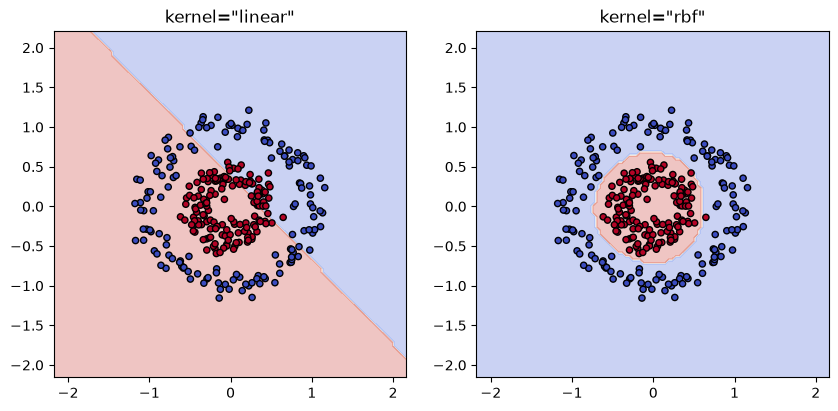

In [10]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    model = make_pipeline(StandardScaler(), SVC(kernel=kernel)).fit(Xc_train, yc_train)
    DecisionBoundaryDisplay.from_estimator(model, Xc, response_method="predict",
                                           cmap="coolwarm", alpha=0.3, ax=ax)
    ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolors="k", s=20)
    ax.set_title(f'kernel="{kernel}"')
plt.show()

### Bonus · KNN from scratch in 3 lines of NumPy

In [11]:
def knn_predict(X_train, y_train, x_new, k=5):
    distances = np.linalg.norm(X_train - x_new, axis=1)   # 1. distance to every training point
    nearest = np.argsort(distances)[:k]                   # 2. the k closest
    return np.bincount(y_train[nearest]).argmax()         # 3. majority vote

X_train_z = scaler.transform(X_train)     # scaled with the training data's mean and std (Step 4)
X_test_z = scaler.transform(X_test)
ours = np.array([knn_predict(X_train_z, y_train, x) for x in X_test_z])
print("Our accuracy:", round(np.mean(ours == y_test), 2))
print("Same predictions as scikit-learn?", np.array_equal(ours, knn.predict(X_test)))
# Our accuracy: 0.92
# Same predictions as scikit-learn? True

Our accuracy: 0.92
Same predictions as scikit-learn? True


- `axis=1` gives one distance per training row. `np.argsort` returns the positions that would sort them, so `[:k]` keeps the k closest.
- `np.bincount` counts the votes for each label and `argmax` picks the label with the most. That's the entire model: no training at all, just stored data and a vote.